Tolerance: 0.001
  - Jacobi steps: 4
  - Gauss-Seidel steps: 4
------------------------------


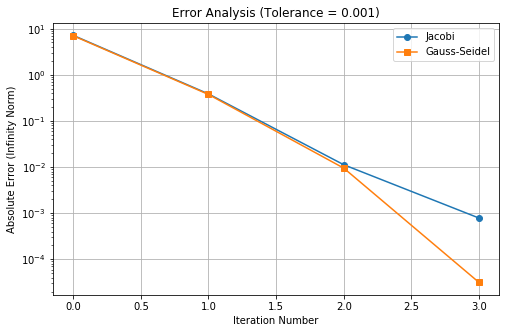

Tolerance: 1e-06
  - Jacobi steps: 7
  - Gauss-Seidel steps: 5
------------------------------


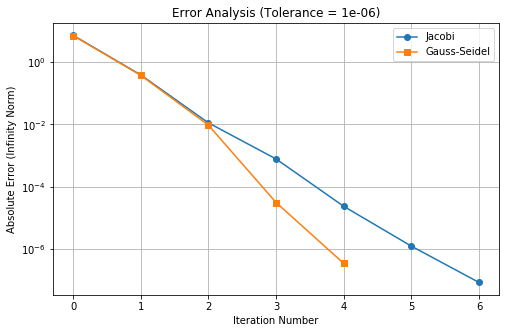

Tolerance: 1e-09
  - Jacobi steps: 9
  - Gauss-Seidel steps: 7
------------------------------


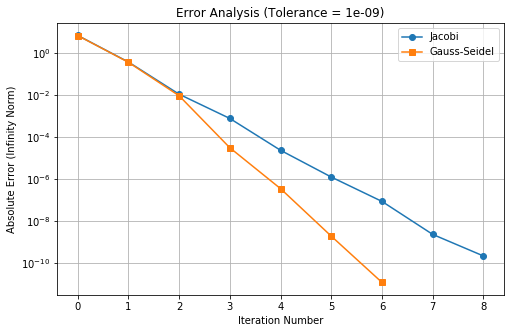

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def gauss_seidel(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors = []
    for k in range(max_iterations):
        x_old = x.copy()
        for i in range(n):
            s1 = sum(A[i][j] * x[j] for j in range(i))
            s2 = sum(A[i][j] * x_old[j] for j in range(i + 1, n))
            x[i] = (b[i] - s1 - s2) / A[i][i]
            
        diff = np.linalg.norm(x - x_old, ord=np.inf)
        errors.append(diff)
        
        if diff < tol:
            return x, k + 1, errors
    return x, max_iterations, errors

def jacobi(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors = []
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            # Jacobi uses only values from the previous iteration
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
            
        diff = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(diff)
        x = x_new
        
        if diff < tol:
            return x, k + 1, errors
    return x, max_iterations, errors
            
A = np.array([[3.0, -0.1, -0.2],[0.1, 7.0, -0.3],[0.3, -0.2, 10.0]])
b = np.array([7.85, -19.3, 71.4])
x0 = np.array([0.0, 0.0, 0.0])
tolerances = [1e-3, 1e-6, 1e-9]

results = []

for t in tolerances: 
    results_j = jacobi(A, b, x0, t, 100)
    j_steps = results_j[1]
    j_err_list = results_j[2]
    
    results_gs = gauss_seidel(A, b, x0, t, 100)
    gs_steps = results_gs[1]
    gs_err_list = results_gs[2]
    
    print(f"Tolerance: {t}")
    print(f"  - Jacobi steps: {j_steps}")
    print(f"  - Gauss-Seidel steps: {gs_steps}")
    print("-" * 30)

    plt.figure(figsize=(8, 5)) ##Asked ChatGPT for help plotting as the plot wouldn't print
    plt.semilogy(j_err_list, label="Jacobi", marker='o')
    plt.semilogy(gs_err_list, label="Gauss-Seidel", marker='s')

    plt.title(f"Error Analysis (Tolerance = {t})")
    plt.xlabel("Iteration Number")
    plt.ylabel("Absolute Error (Infinity Norm)")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
## The tolerance affects the number of iterations needed as reducing the tolerance increases the number of iterations. This means there is an inverse relationship in determining the number of iterations needed for convergence.